In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import norm
import os
import glob
import re

In [2]:
# GLOBAL VARIABLES

#directories and paths
DATASET_PATH = "../../ws25_aia_complete_data"
LOGS_DIR = "logs"
SCENARIO_SEP = "maps-"
LOG_CCI = "component_container_isolated"


#NAMES COLUMNS
TIMESTAMP = 'timestamp'
FRAME = 'frame'
POSITION_X = "position.x"
POSITION_Y = "position.y"
ORIENTATION_YAW = 'orientation.yaw'

#FRAMES
REAL_POSE = 'nav2_turtlebot4_base_link_gt'
ESTIMATED_POSE = 'base_link'

#PATERN_LOG
PATTERN_BR = r"\[(.*?)\]"

#LOGS MSG IDENTIFIERS
LOGS_SUCCESS = 'Goal succeeded'
LOGS_FAILED = 'Goal failed'
LOGS_BEGIN = 'Begin navigating'
LOGS_NEW_PATH = 'Passing new path to controller.'
LOGS_PROGRESS_F = 'Failed to make progress'
LOGS_PLAN_F = 'GridBased plugin failed to plan'

#LOCALIZATION ERROR
COUNT_IN_CONSISTENT = 3

In [23]:
#Objects

# Class with the data of a ros iteration in a scenario
class DataProcessed:
    def __init__(self, scenario, run_n, csv_file):
        #general info
        self.scenario = scenario
        self.run_n = run_n
        
        #csv info
        self.csv_file = csv_file
        if os.path.exists(csv_file):
            self.df = pd.read_csv(
                csv_file,
                comment='#',       
                sep=',',           
                quotechar='"',     
                engine='python'
            )
        else:
            #csv does not exist
            self.csv_file = None
        self.position_error = np.array([])
        self.yaw_error = np.array([])
        
        #logs info
        self.logs = []
        self.failure_run = True
        self.init_t = None
        self.end_t = None

        #anomalies info
        self.anomalies = []
        self.unique_anomalies = []

    def add_log(self, log):
        self.logs.append(log)

        #special logs information about begining and end of a run
        if 'Begin navigating' in log.msg:
            self.init_t = log.time
        if 'Goal succeeded' in log.msg:
            self.failure_run = False
            self.end_t = log.time
        if 'Goal failed' in log.msg:
            self.end_t = log.time

    # Get Pose error of the scenario (2D) in form of position_error, yaw_error, timestamp
    # given deduced pose info and real pose info
    def calculate_pose_error(self):
        if self.csv_file == None:
            return
        
        deduced_pose = self.df.loc[self.df[FRAME] == ESTIMATED_POSE]
        real_pose = self.df.loc[self.df[FRAME] == REAL_POSE]
        
        #since is 2D just take position.x and y and orientation.z and w.
        deduced_position_x = deduced_pose[POSITION_X].to_numpy()
        deduced_position_y = deduced_pose[POSITION_Y].to_numpy()
        deduced_yaw = deduced_pose[ORIENTATION_YAW].to_numpy()
        deduced_timestamp = deduced_pose[TIMESTAMP].to_numpy()
    
        real_position_x = real_pose[POSITION_X].to_numpy()
        real_position_y = real_pose[POSITION_Y].to_numpy()
        real_yaw = real_pose[ORIENTATION_YAW].to_numpy()
        real_timestamp = real_pose[TIMESTAMP].to_numpy()
        
        #get interpolation of real_pose to timestamp of deduced_pose.
        real_position_x_inter = np.interp(deduced_timestamp, real_timestamp, real_position_x)
        real_position_y_inter = np.interp(deduced_timestamp, real_timestamp, real_position_y)
        real_yaw_inter = np.interp(deduced_timestamp, real_timestamp, real_yaw)
    
        #now it is possible to get the vectoriced error
        dx = deduced_position_x - real_position_x_inter
        dy = deduced_position_y - real_position_y_inter
        position_error = np.sqrt(dx**2 + dy**2)
        self.position_error = np.stack((np.array(position_error), np.array(deduced_timestamp)), axis=1)

        #get yaw error.
        yaw_error = deduced_yaw - real_yaw_inter
        #normalice between [-pi, pi]
        yaw_error = (yaw_error + np.pi) % (2 * np.pi) - np.pi
        self.yaw_error = np.stack((yaw_error, deduced_timestamp), axis=1)

    def detect_log_anomalies(self):

        anomalies = []

        for log in self.logs:
    
            # No progress anomaly
            if "Failed to make progress" in log.msg:
                anomalies.append(("no_progress", log.time))
    
            # Planner failure
            if "Failed to create a plan" in log.msg:
                anomalies.append(("planner_failure", log.time))
    
            # Collision
            if "Collision Ahead" in log.msg:
                anomalies.append(("collision", log.time))
    
            # Stuck anomalies
            if "spin failed" in log.msg or "backup failed" in log.msg:
                anomalies.append(("stuck", log.time))
    
            # Fatal initialization
            if log.type == "FATAL":
                anomalies.append(("fatal_initialization", log.time))

            # Goal failed
            if "Goal failed" in log.msg:
                anomalies.append(("goal_failure", log.time))

        if len(self.logs) == 0:
            anomalies.append(("no_initiation", 0))

        
        self.anomalies += anomalies

    def detect_time_anomalie(self, scenario_data):
        time_run = []
        
        for data in scenario_data:
            if data.init_t is not None and data.end_t is not None:
                time_run.append(data.end_t - data.init_t)

        #since we know the number of runs is low, we use median instead of mean which also is not influenced by outliers
        if len(time_run) != 0:
            med = np.median(time_run)
            MAD = np.median(np.abs(time_run - med))  # Median of absolute desviation

            # tipic threshold: 3 * MAD
            umbral = med + 3 * MAD
            if self.init_t is not None and self.end_t is not None:
                if self.end_t - self.init_t > umbral:
                    self.anomalies.append(("time_outlier", self.end_t))
    
    def detect_position_anomalie(self, umbral_error):
        if self.csv_file == None:
            return

        anomalies = []
        in_outlier = False
        count_in = 0
        
        position_sorted = self.position_error[self.position_error[:, 1].argsort()]
        for p_err, t in position_sorted:
            if p_err > umbral_error:
                if not in_outlier:
                    in_outlier = True
                else:
                    if count_in == COUNT_IN_CONSISTENT:
                        anomalies.append(("position_error", t)) 
                count_in = count_in + 1
            elif p_err < umbral_error and in_outlier:
                in_outlier = False
                count_in = 0
                
        self.anomalies += anomalies

    def clean_anomalies(self):
        self.anomalies = []

    def get_unique_anomalies(self):
        if len(self.anomalies) != 0:
            self.unique_anomalies = set(a[0] for a in self.anomalies)
        return self.unique_anomalies
        
#Class for the logs of ros
class LogsRos:
    def __init__(self, type_msg, time, sender, msg):
        self.type = type_msg
        self.time = time
        self.sender = sender
        self.msg = msg

cmap = plt.get_cmap('tab10')

In [24]:
#Get data stored and preprocessing
dataset = []

for scenario_dir in os.listdir(DATASET_PATH):
    scenario = scenario_dir.split(SCENARIO_SEP)[1]
    scenario_path = os.path.join(DATASET_PATH, scenario_dir)
    scenario_group = []
    for run_n in os.listdir(scenario_path):
        #get csv
        csv_file = os.path.join(scenario_path, run_n, "poses.csv")
        data = DataProcessed(scenario, int(run_n), csv_file)
        data.calculate_pose_error()
        #get logs
        logs_file = glob.glob(scenario_path + "/" + run_n + "/" + LOGS_DIR + "/" + LOG_CCI + "*")
        if len(logs_file) != 0 and os.path.isfile(logs_file[0]):
            with open(logs_file[0], "r") as f:
                for line in f:
                    # get strings between []
                    brakets = re.findall(PATTERN_BR, line)
                    if len(brakets) == 3:
                        # log info are structured like [type] [time] [sender] : msg
                        type_msg = brakets[0]
                        time = float(brakets[1])
                        sender = brakets[2]
                        msg = line.split("]:")[-1].strip()
                        log = LogsRos(type_msg, time, sender, msg)
                        #Add log to the datasetRos object
                        data.add_log(log)
                        
        scenario_group.append(data)
    dataset.append(scenario_group)     


umbral_position_error:  0.877198388027938


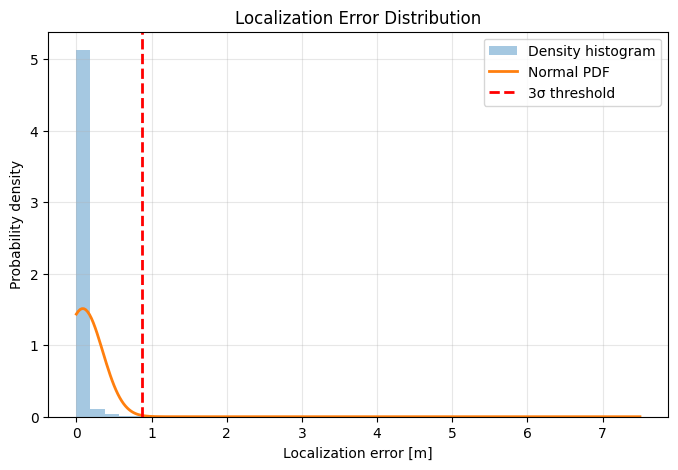

In [25]:
#Get mean of localization error and variance to determine when the localization error is anomaly big
position_error_total = []

for scenario_group in dataset:
    for data in scenario_group: 
        if data.csv_file != None:
            position_error_total.extend(data.position_error[:,0])

position_error_total = np.array(position_error_total)
mean = position_error_total.mean()
std = position_error_total.std()
umbral_position_error = mean + 3 * std
print( "umbral_position_error: " , umbral_position_error)

# PDF curve
x = np.linspace(0, position_error_total.max(), 300)
pdf = norm.pdf(x, mean, std)

plt.figure(figsize=(8,5))

# Density histogram
plt.hist(position_error_total, bins=40, density=True, alpha=0.4, label="Density histogram")

# PDF curve
plt.plot(x, pdf, linewidth=2, label="Normal PDF")

# Threshold line
plt.axvline(umbral_position_error, color='r', linestyle="--", linewidth=2, label="3σ threshold")

plt.xlabel("Localization error [m]")
plt.ylabel("Probability density")
plt.title("Localization Error Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [26]:
#Get Anomalies
all_anomalies = []
all_anomalies_f_run = []
unique_anomalies = []
unique_anomalies_f_run = []


for scenario_group in dataset:
    for data in scenario_group: 
        data.clean_anomalies()
        data.detect_log_anomalies()
        data.detect_time_anomalie(scenario_group)
        data.detect_position_anomalie(umbral_position_error)

        unique_a = data.get_unique_anomalies()
        unique_anomalies.extend(unique_a)
        all_anomalies.extend(data.anomalies)
        if data.failure_run:
            all_anomalies_f_run.extend(data.anomalies)
            unique_anomalies_f_run.extend(unique_a)



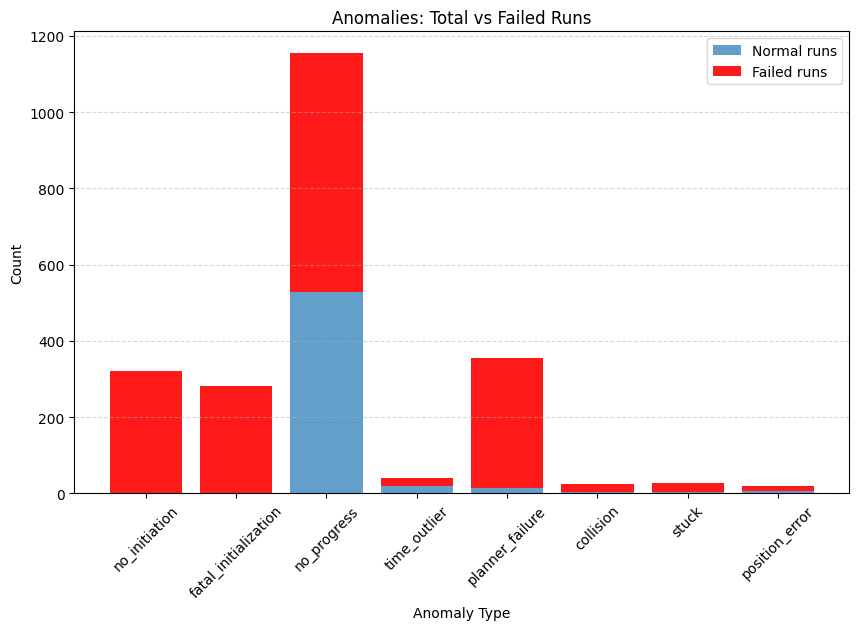

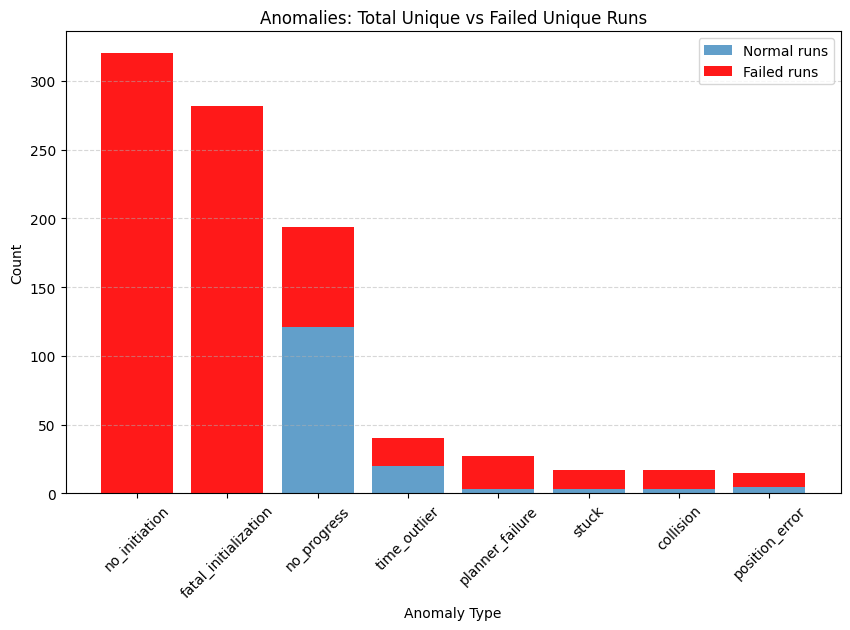

In [27]:
#Analyse anomalies
 
# Flatten lists
flattened_all = [a[0] for a in all_anomalies]
flattened_fail = [a[0] for a in all_anomalies_f_run]

# Count occurrences
count_all = Counter(flattened_all)
count_fail = Counter(flattened_fail)
count_uall = Counter(unique_anomalies)
count_ufail = Counter(unique_anomalies_f_run)

#total
anomaly_types = list(count_all.keys())
total_counts = np.array([count_all[t] for t in anomaly_types])
fail_counts = np.array([count_fail.get(t, 0) for t in anomaly_types])
normal_counts = total_counts - fail_counts

# Plot stacked bar chart
plt.figure(figsize=(10,6))
plt.bar(anomaly_types, normal_counts, label="Normal runs", alpha=0.7)
plt.bar(anomaly_types, fail_counts, bottom=normal_counts, label="Failed runs", alpha=0.9, color='r')
    
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.title("Anomalies: Total vs Failed Runs")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Unique
anomaly_types = list(count_uall.keys())
total_counts = np.array([count_uall[t] for t in anomaly_types])
fail_counts = np.array([count_ufail.get(t, 0) for t in anomaly_types])
normal_counts = total_counts - fail_counts

# Plot stacked bar chart
plt.figure(figsize=(10,6))
plt.bar(anomaly_types, normal_counts, label="Normal runs", alpha=0.7)
plt.bar(anomaly_types, fail_counts, bottom=normal_counts, label="Failed runs", alpha=0.9, color='r')
    
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.title("Anomalies: Total Unique vs Failed Unique Runs")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


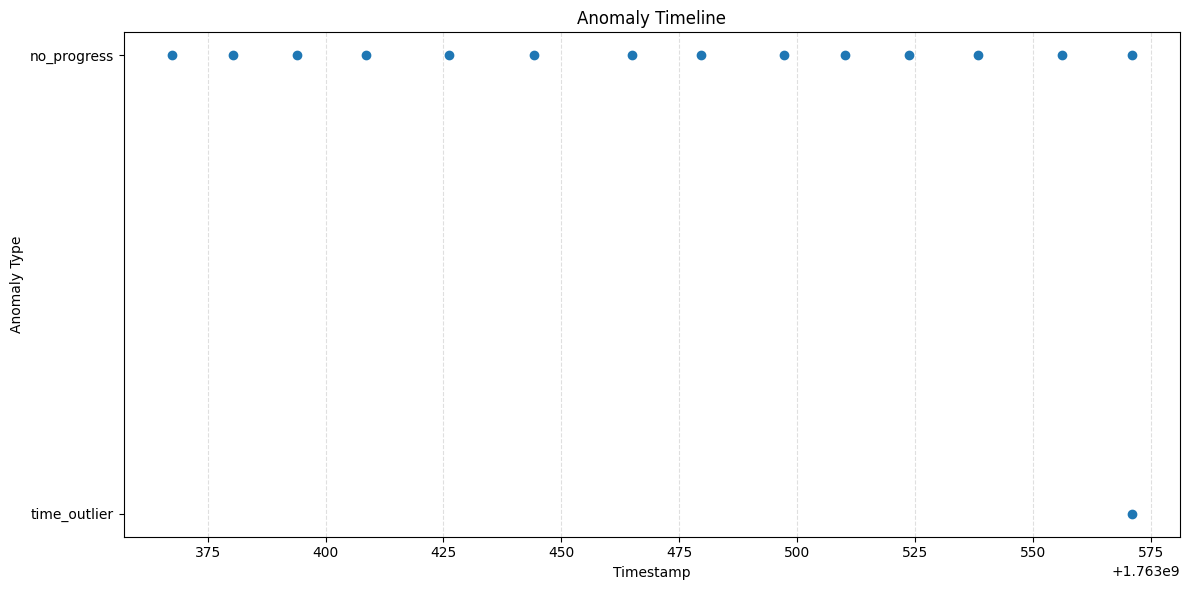

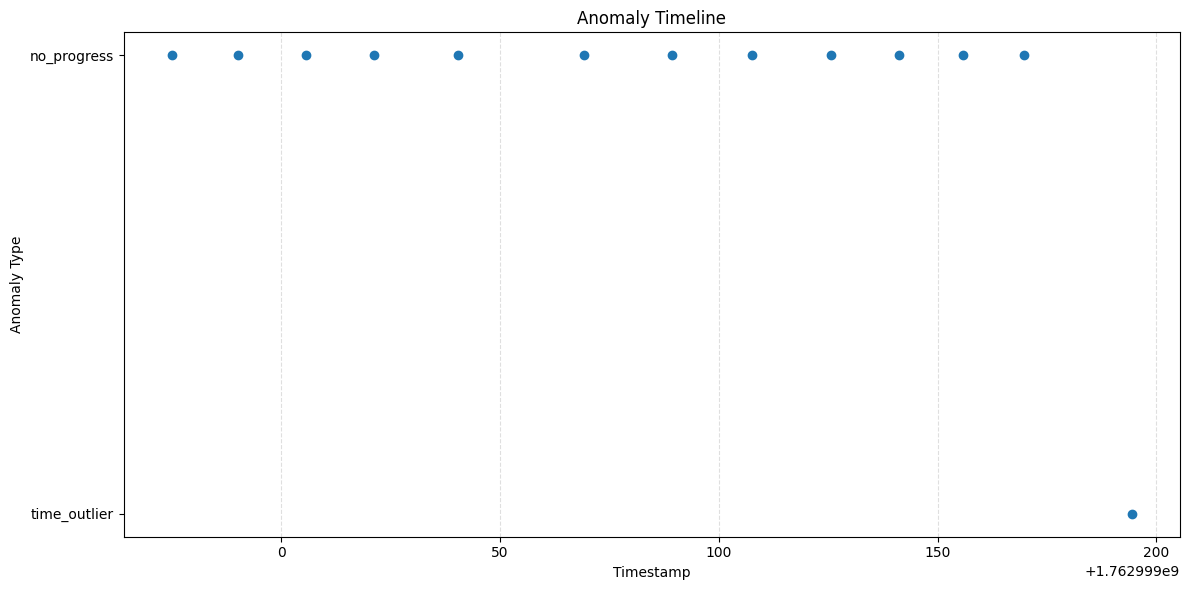

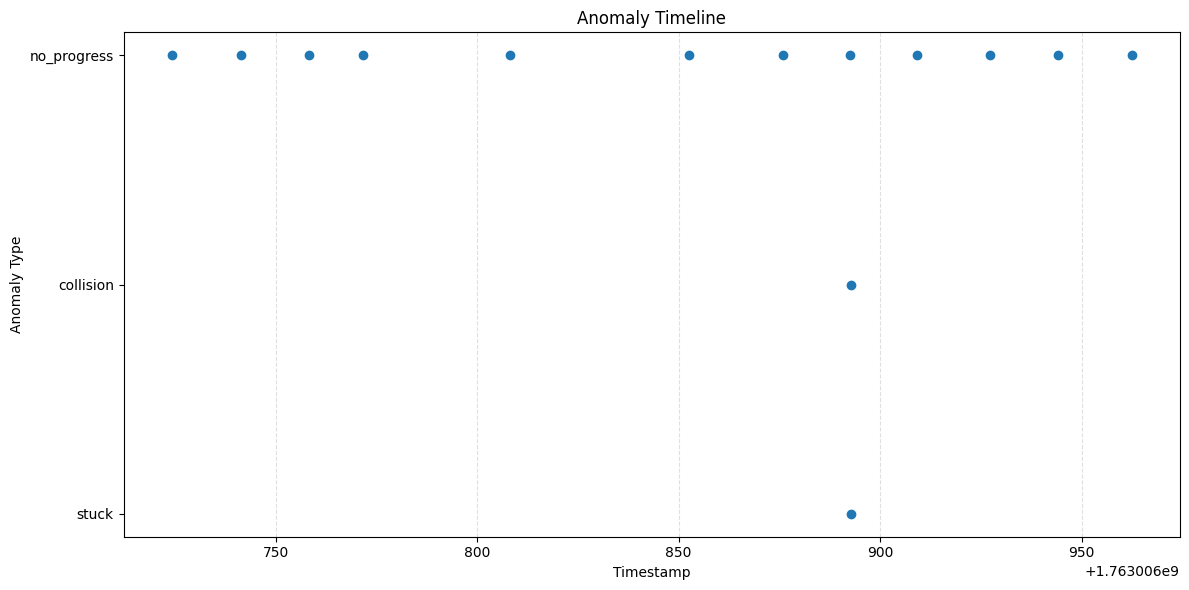

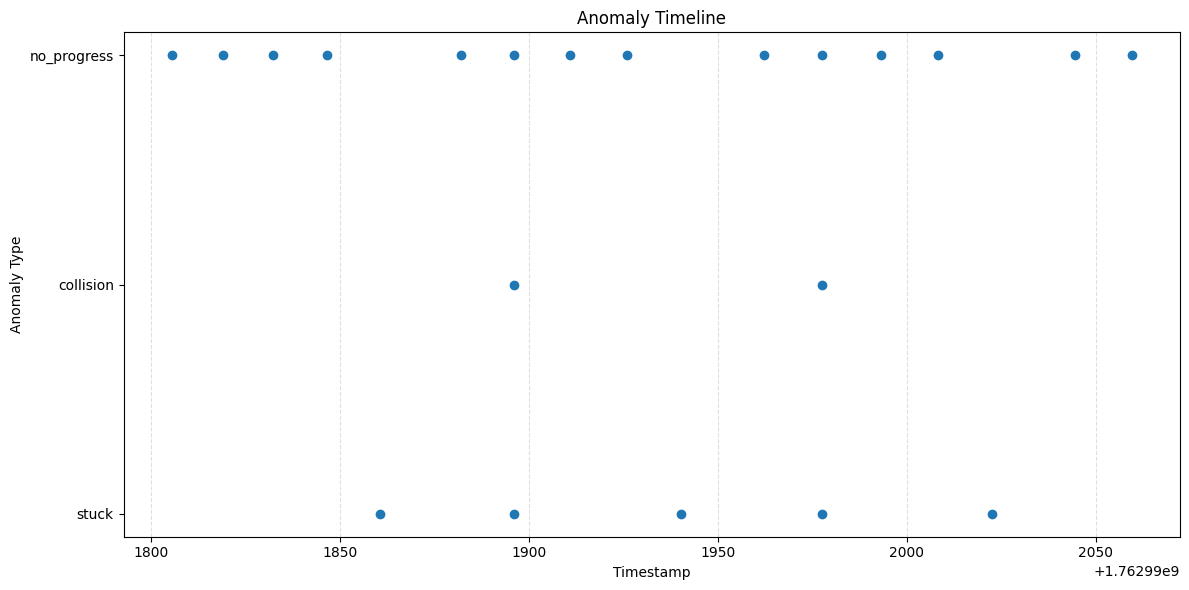

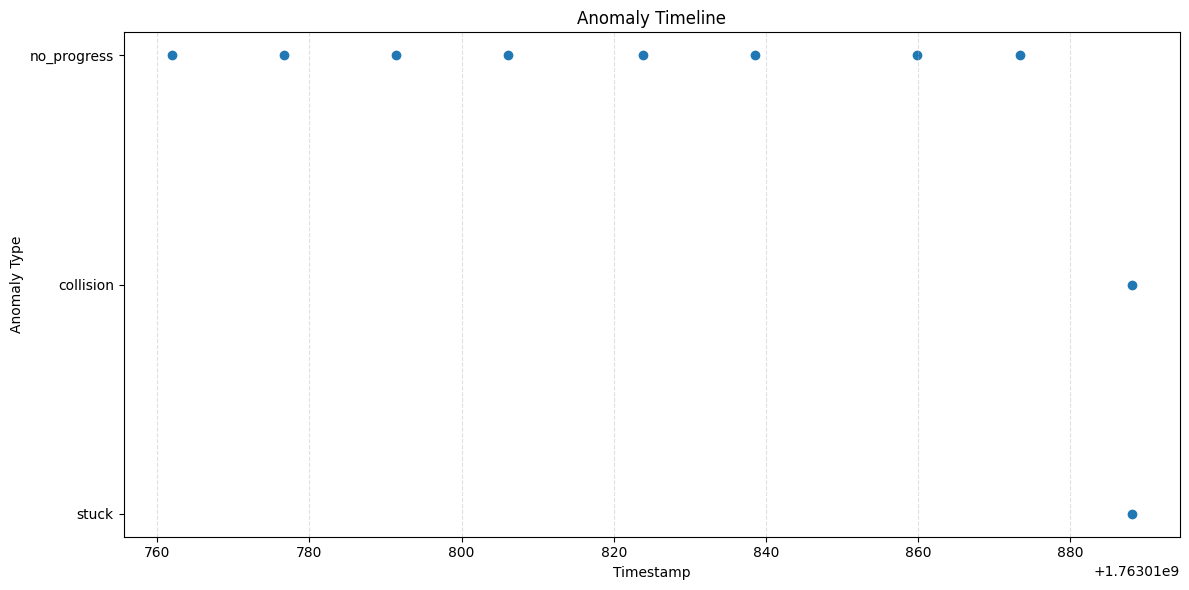

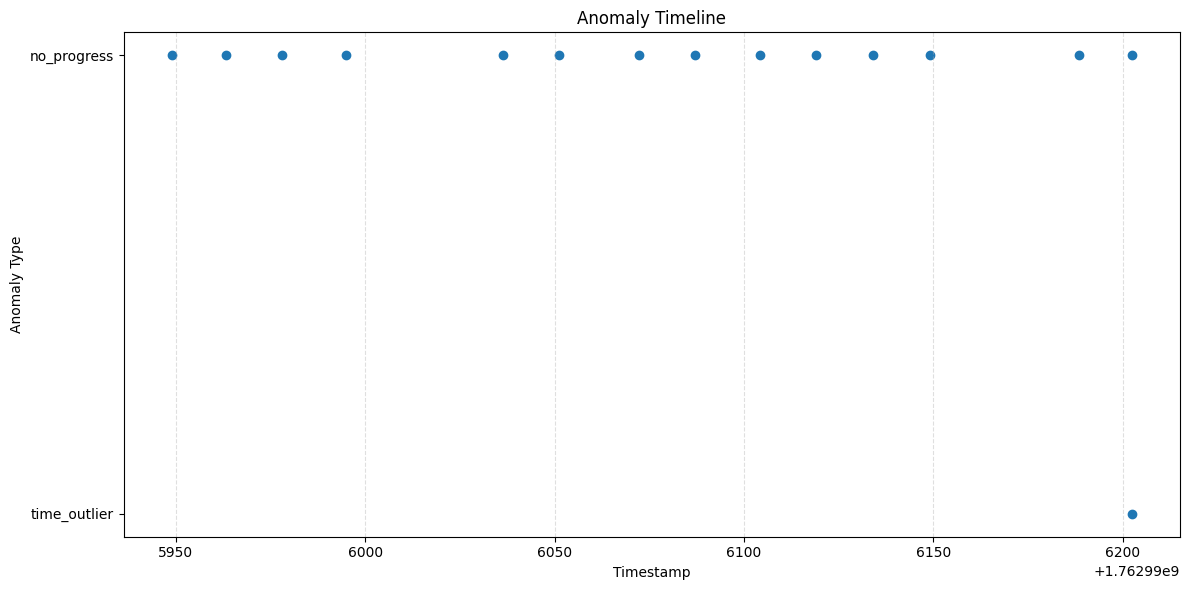

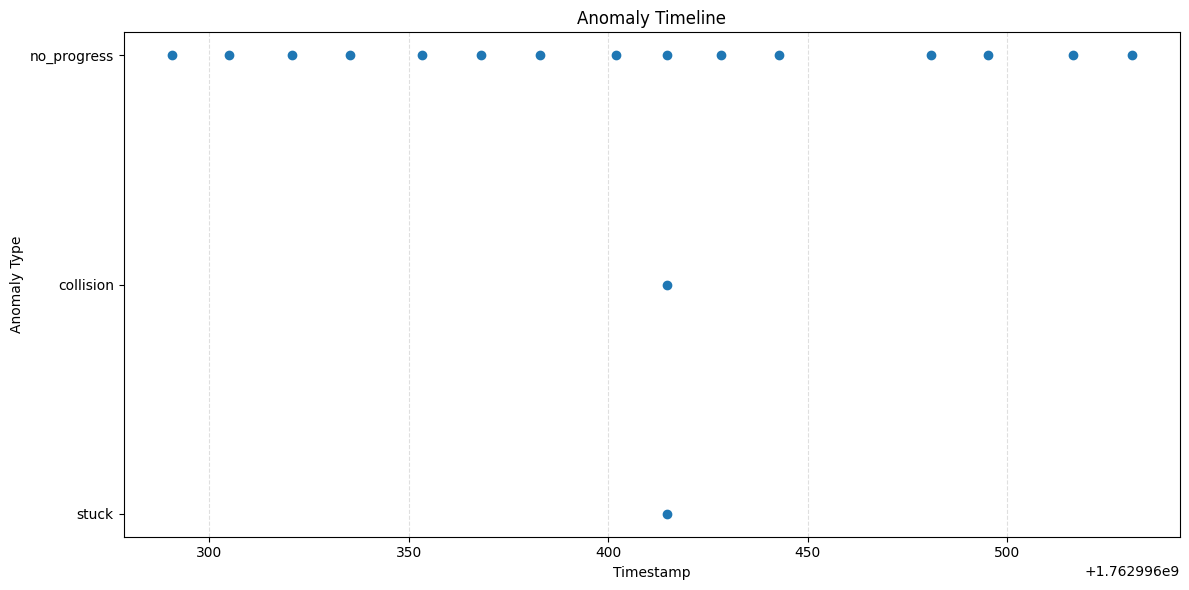

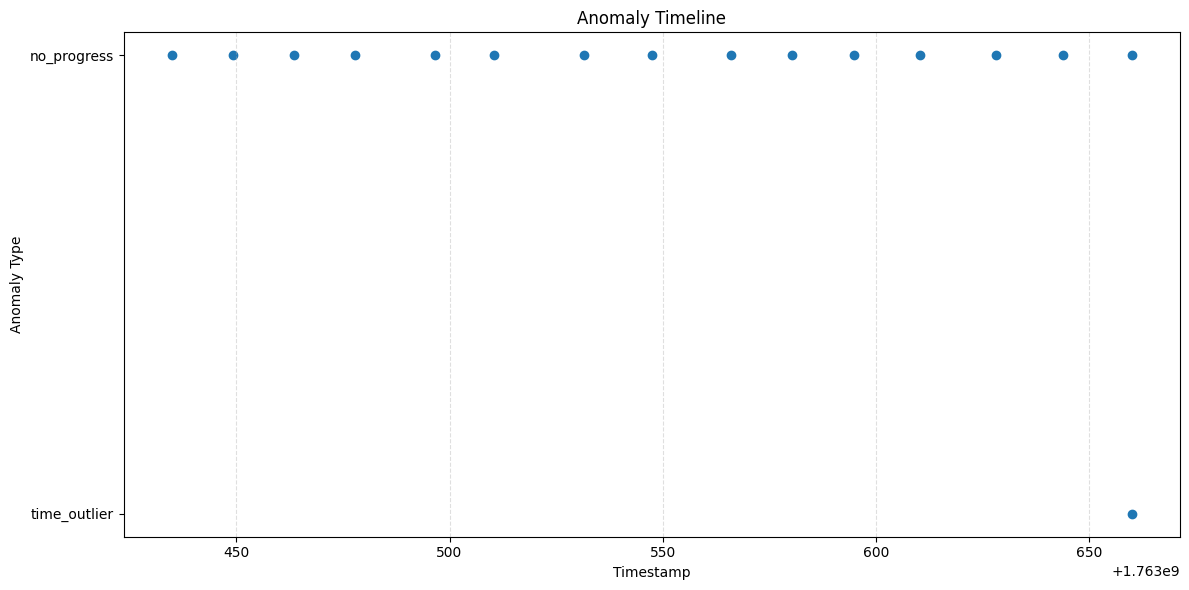

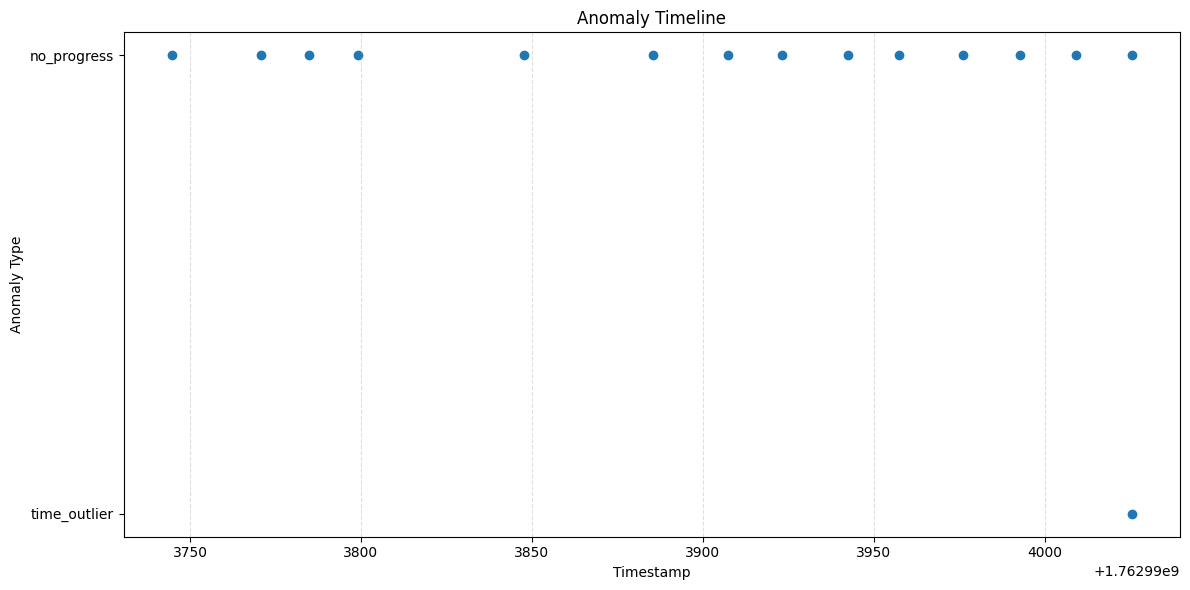

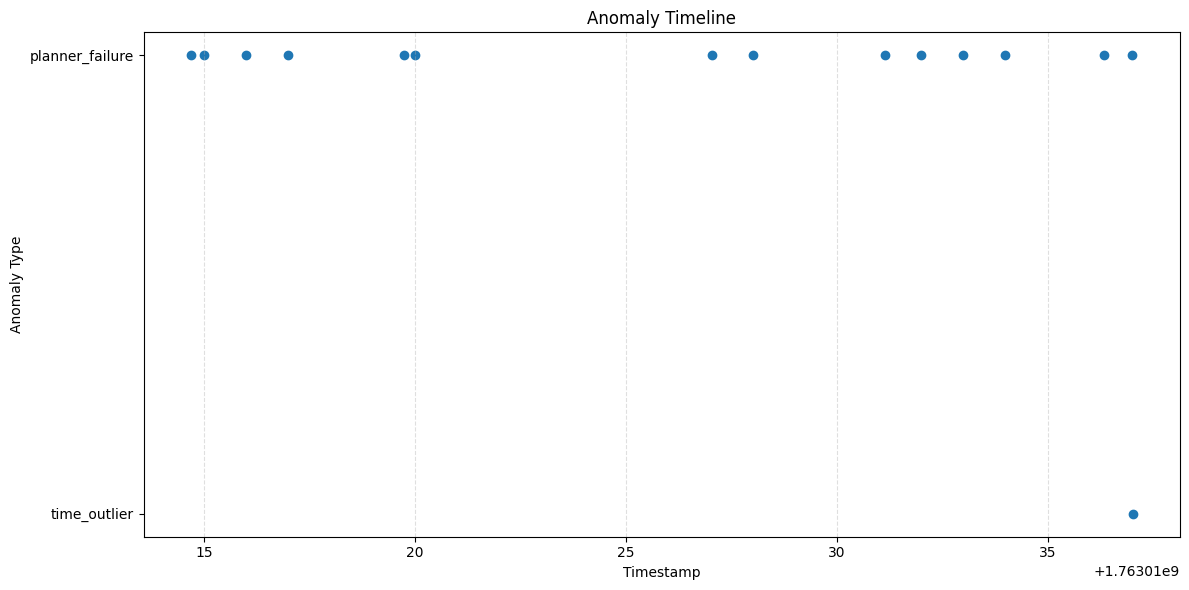

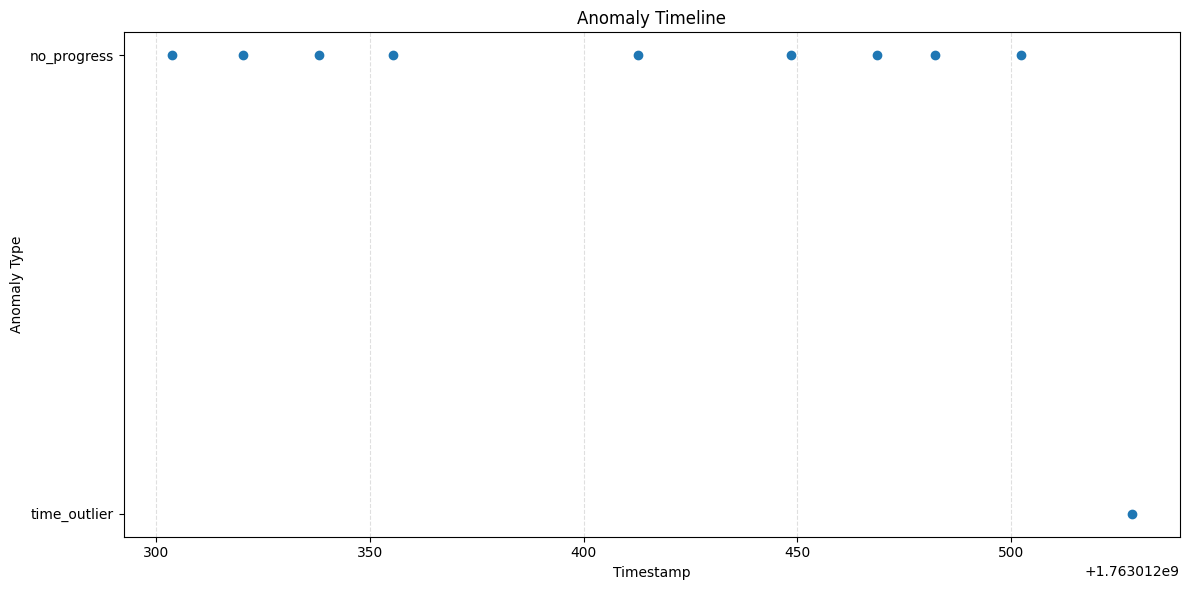

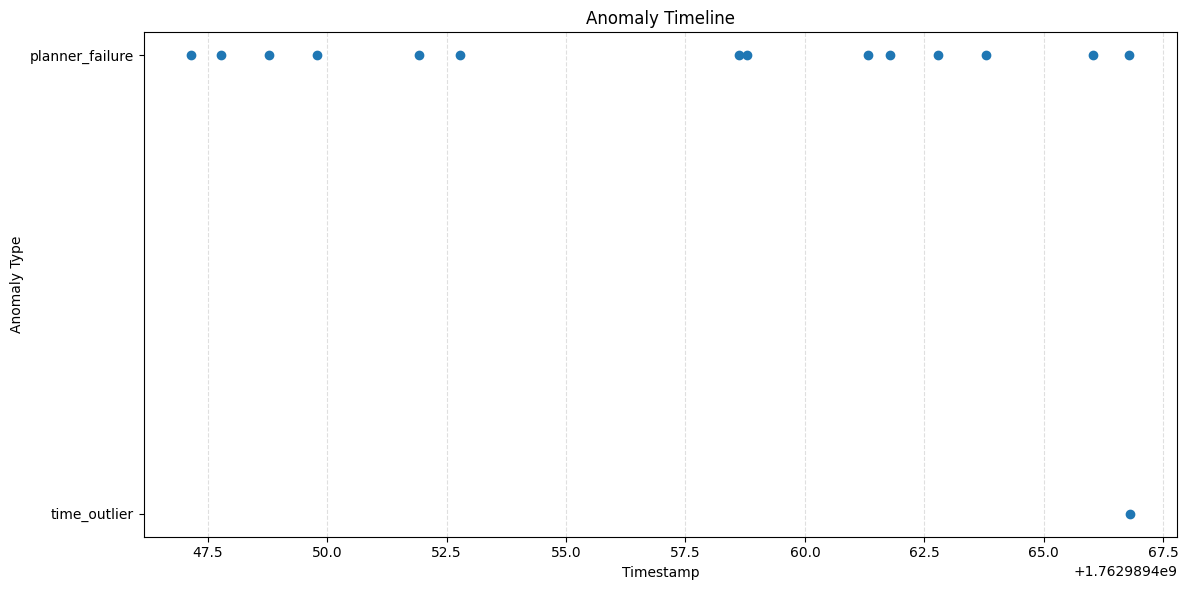

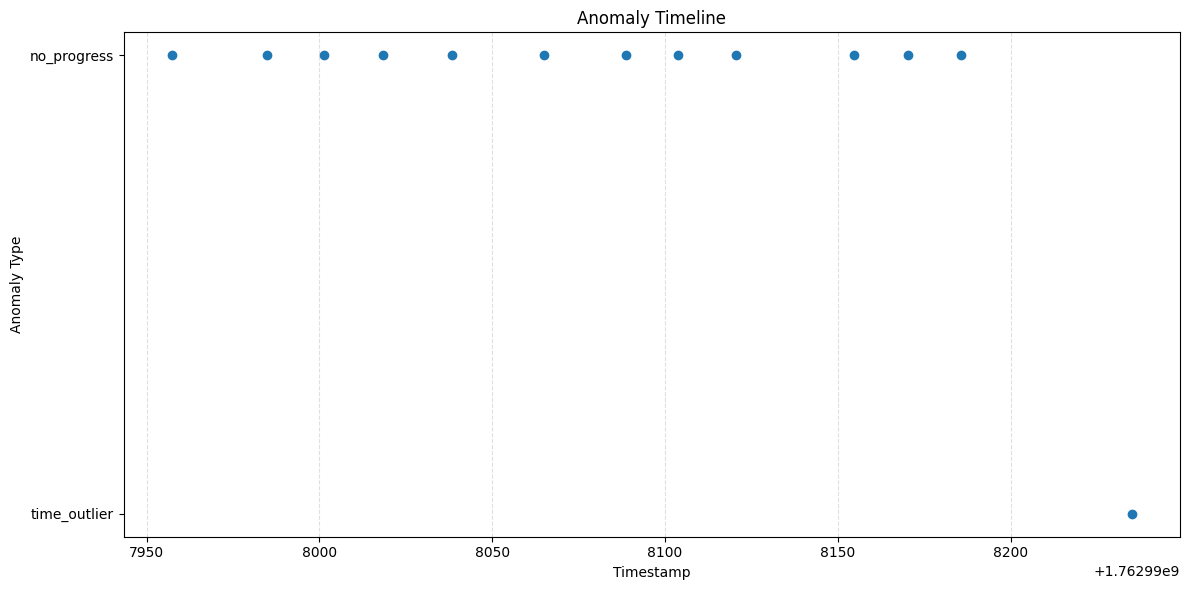

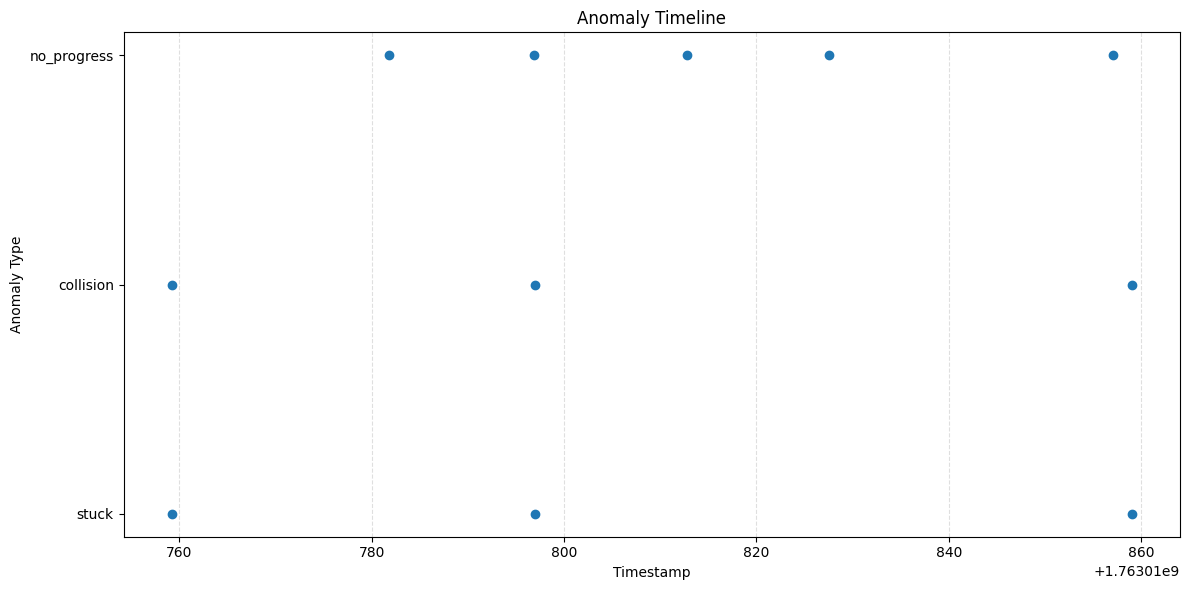

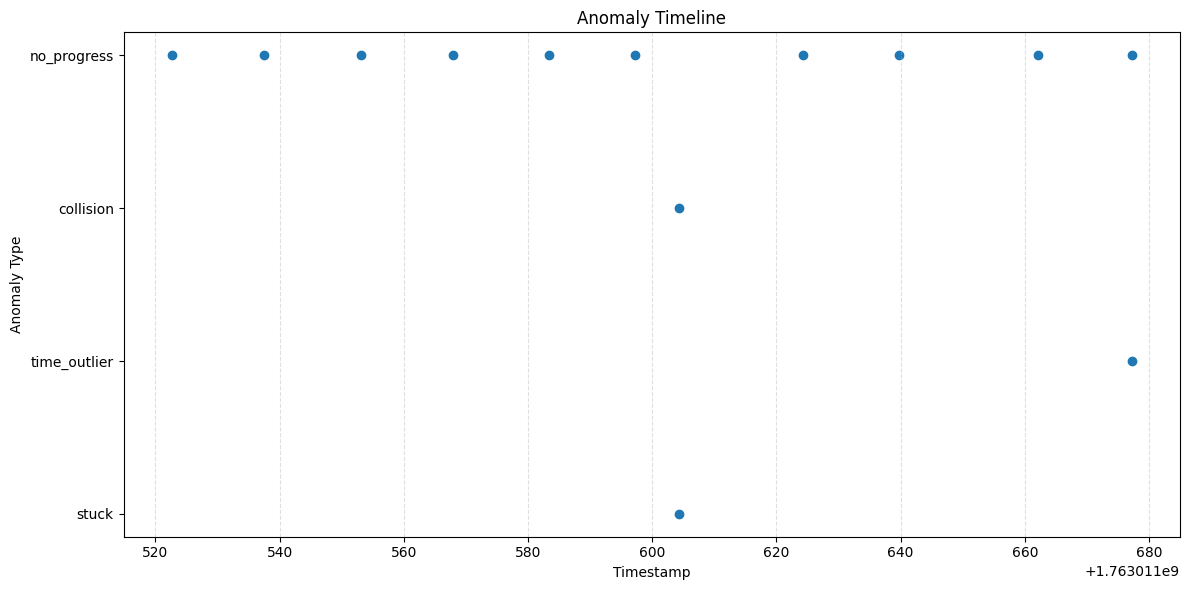

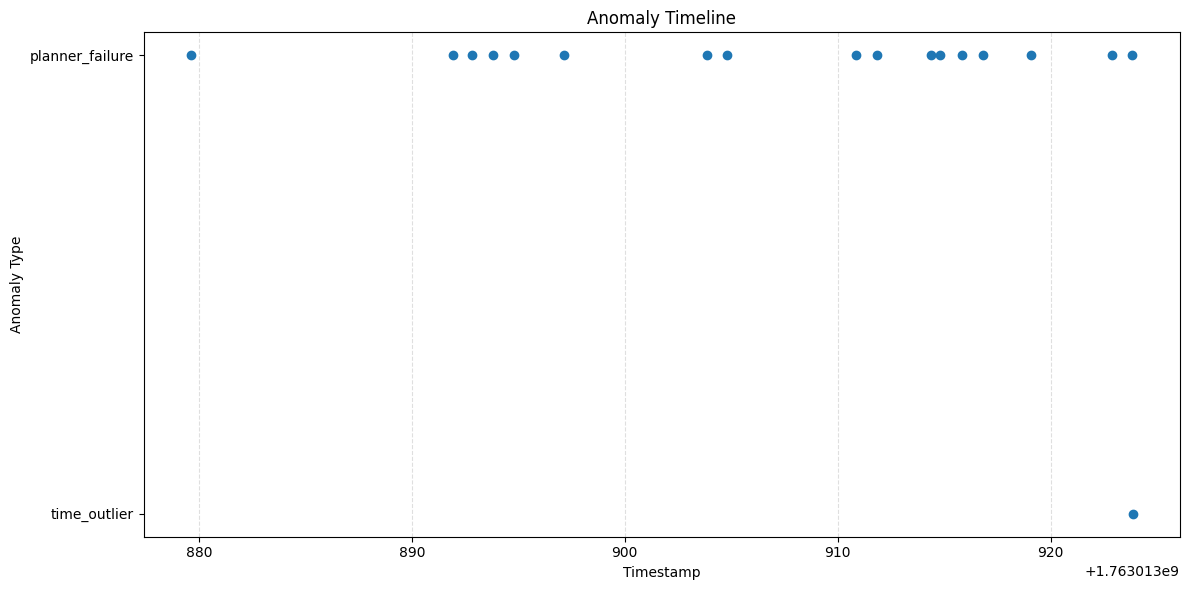

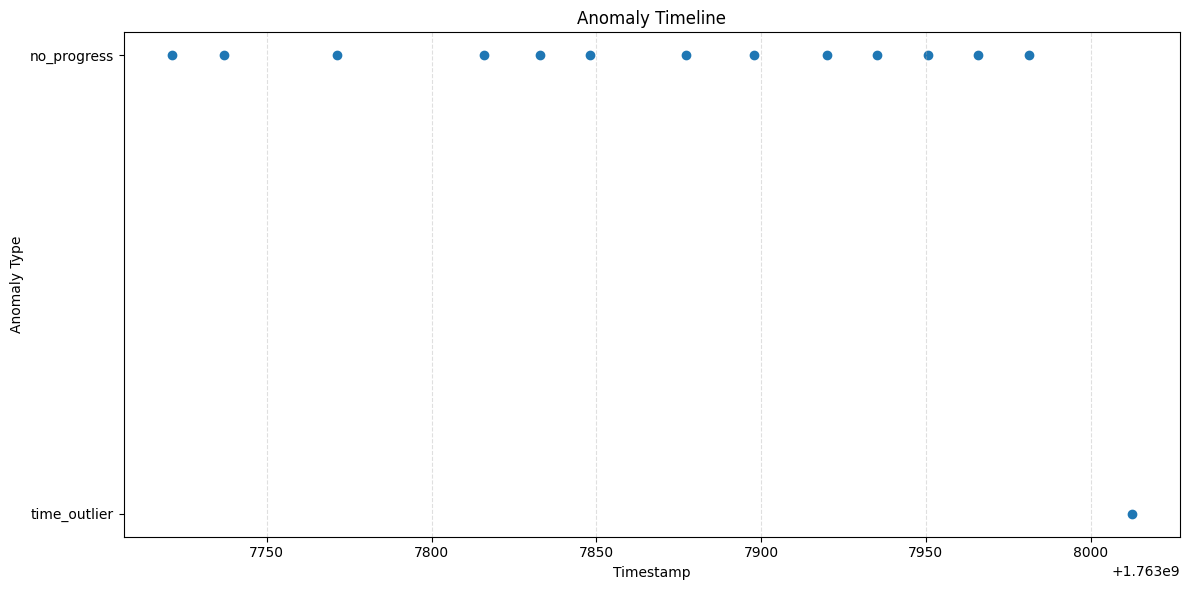

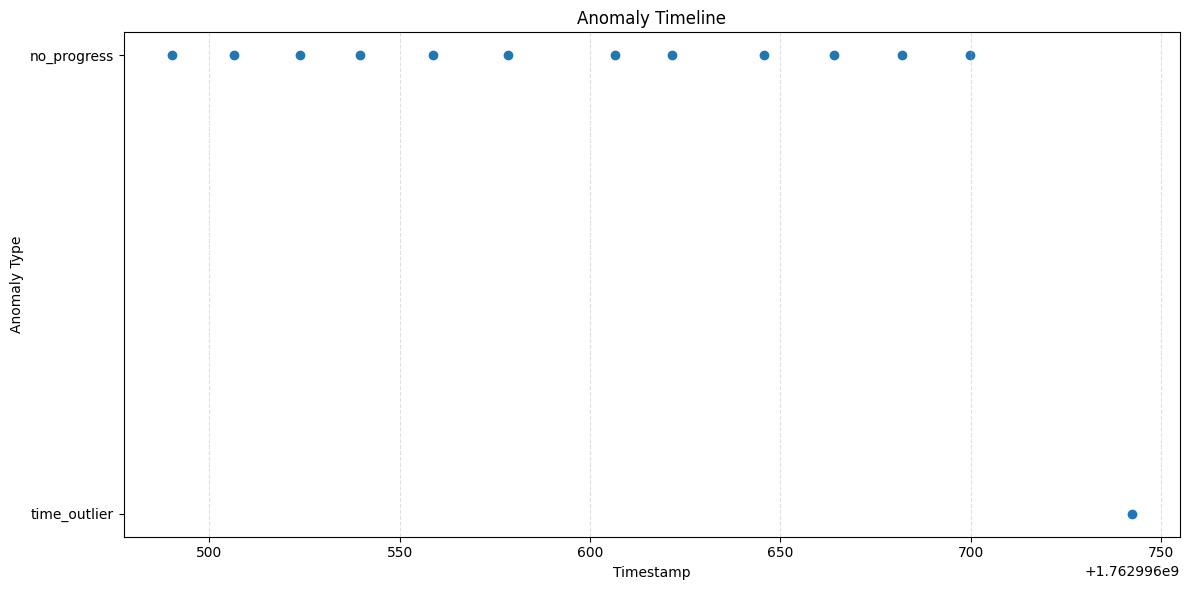

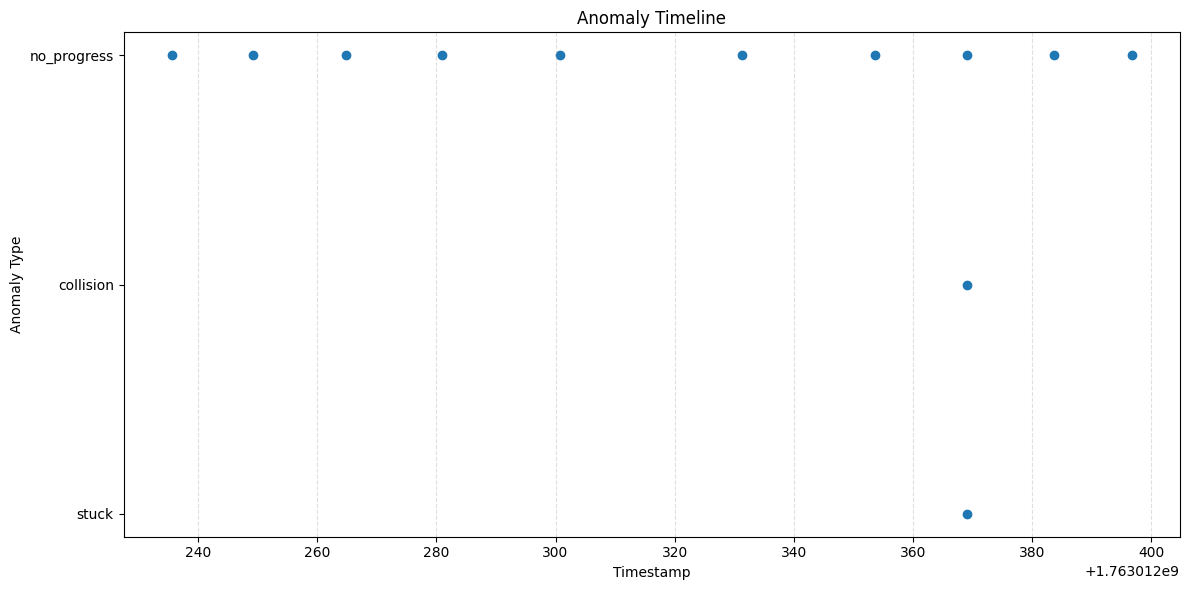

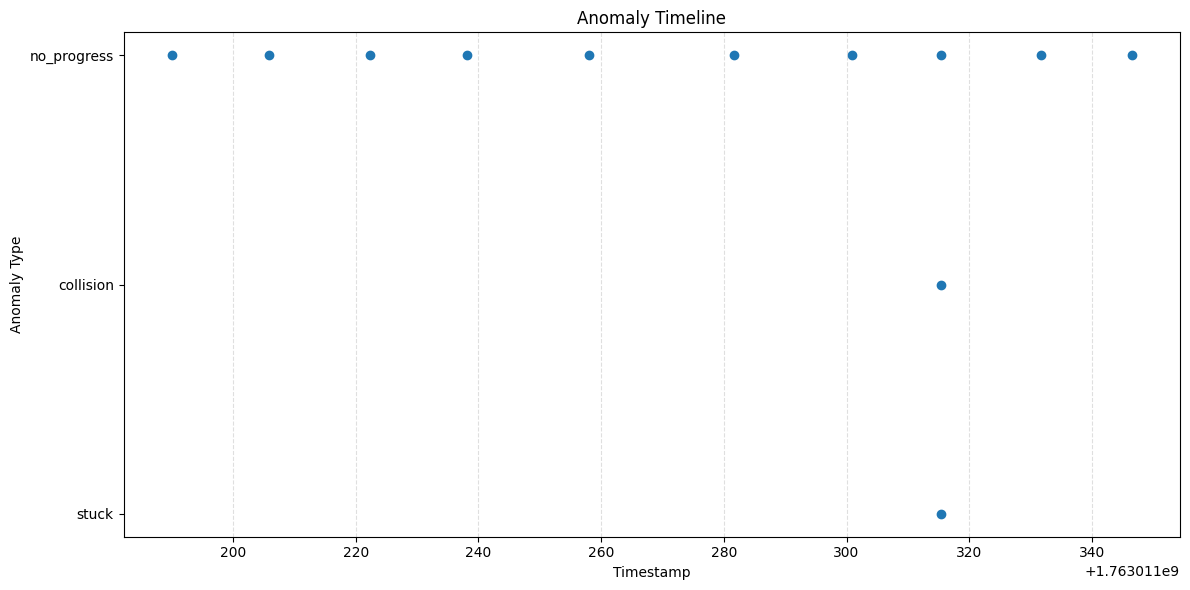

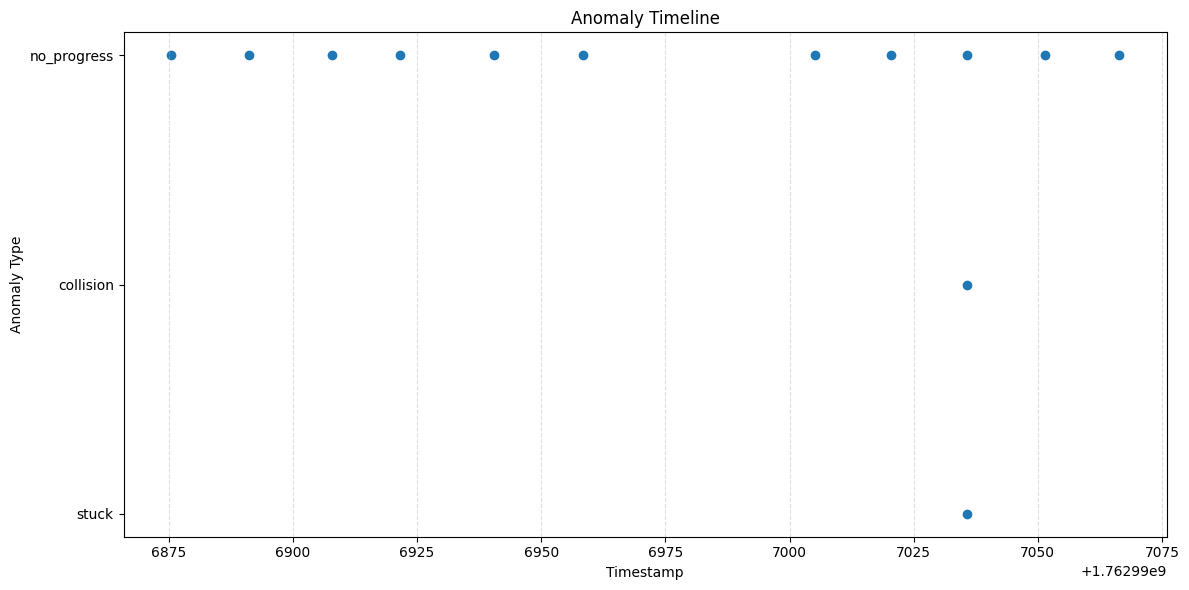

In [43]:
def plot_anomaly_timeline(flattened_anomalies):
    """
    flattened_anomalies: list of (anomaly_type, timestamp)
    Example: [("COLLISION", 12.5), ("FOLLOW_FAIL", 88.1)]
    """

    if len(flattened_anomalies) == 0:
        print("No anomalies to plot.")
        return

    # Sort by timestamp
    flattened_anomalies = sorted(flattened_anomalies, key=lambda x: x[1])

    # Extract unique types and assign y-levels
    anomaly_types = list(set(a[0] for a in flattened_anomalies))
    type_to_y = {atype: i for i, atype in enumerate(anomaly_types)}

    # Prepare X (time) & Y (anomaly type levels)
    x_vals = [a[1] for a in flattened_anomalies]
    y_vals = [type_to_y[a[0]] for a in flattened_anomalies]

    # Plot
    plt.figure(figsize=(12, 6))
    plt.scatter(x_vals, y_vals)

    plt.yticks(list(type_to_y.values()), list(type_to_y.keys()))
    plt.xlabel("Timestamp")
    plt.ylabel("Anomaly Type")
    plt.title("Anomaly Timeline")
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


for scenario_group in dataset:
    for data in scenario_group: 
        if len(data.anomalies) >= 10 and len(data.unique_anomalies) >= 2:
            plot_anomaly_timeline(data.anomalies)